In [1]:
!pip install pulp


In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import pulp
from scipy.spatial.distance import cdist

sns.set_style("whitegrid")


In [3]:
# load dataset
df = pd.read_csv(r"C:\Users\Thvelonis\Downloads\synthetic_h2_demand_data.csv")

# display dataset
display(df.head())


,Hour,DayOfWeek,Temperature,TrafficIndex,VehicleCount,Weather,H2Demand
0,0,1,12.5,5.0,272.0,Cloudy,224
1,1,1,14.0,5.0,243.0,Cloudy,666
2,2,1,13.6,5.0,222.0,Cloudy,230
3,3,1,14.7,5.0,197.0,Cloudy,740
4,4,1,18.2,5.0,252.0,Sunny,519


In [4]:
# dropping columns that will not be useful in forecasting hydrogen demand
df = df.drop(columns = ["Temperature", "Weather"])

# feature engineering
df["hour_sin"] = np.sin(2 * np.pi * df["Hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["Hour"] / 24)

df["day_sin"] = np.sin(2 * np.pi * (df["DayOfWeek"] - 1) / 7)
df["day_cos"] = np.cos(2 * np.pi * (df["DayOfWeek"] - 1) / 7)

# traffic index
np.random.seed(42)
df["TrafficIndex"] = np.random.uniform(0.3, 1.0, len(df))

# display dataset
display(df.head())


,Hour,DayOfWeek,TrafficIndex,VehicleCount,H2Demand,hour_sin,hour_cos,day_sin,day_cos
0,0,1,0.562178,272.0,224,0.000000,1.000000,0.0,1.0
1,1,1,0.965500,243.0,666,0.258819,0.965926,0.0,1.0
2,2,1,0.812396,222.0,230,0.500000,0.866025,0.0,1.0
3,3,1,0.719061,197.0,740,0.707107,0.707107,0.0,1.0
4,4,1,0.409213,252.0,519,0.866025,0.500000,0.0,1.0


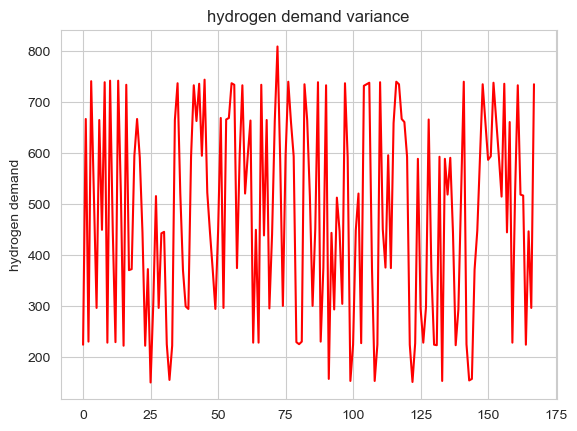

In [5]:
# target variable visualization
plt.figure()
plt.plot(df["H2Demand"], c = "red")
plt.title("hydrogen demand variance")
plt.ylabel("hydrogen demand")
plt.show()


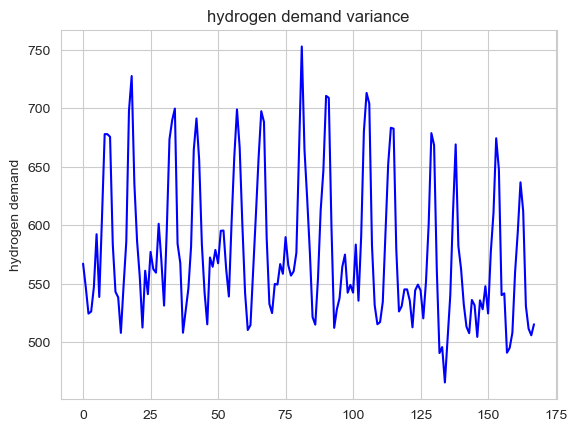

In [6]:
# create a clean synthetic target
base = 400
df["H2Demand"] = (
    base
    + 0.6 * df["VehicleCount"]
    + 5 * df["TrafficIndex"]
    + 5 * df["hour_sin"]
    + np.random.normal(0, 10, len(df))
)

# target variable visualization (again)
plt.figure()
plt.plot(df["H2Demand"], c = "blue")
plt.title("hydrogen demand variance")
plt.ylabel("hydrogen demand")
plt.show()


In [7]:
# checking the data so that there are no missing values
print(df.isnull().sum())


Hour            0
DayOfWeek       0
TrafficIndex    0
VehicleCount    0
H2Demand        0
hour_sin        0
hour_cos        0
day_sin         0
day_cos         0
dtype: int64


In [8]:
# simulate station locations in training data
df["station_x"] = np.random.uniform(0, 10, len(df))
df["station_y"] = np.random.uniform(0, 10, len(df))

# X and y definition
y = df["H2Demand"]  # target variable
X = df[["VehicleCount", "TrafficIndex", "hour_sin", "hour_cos", "day_sin", "day_cos", "station_x", "station_y"]]


In [9]:
# hyperparameters optimization method for the Random Forest model
from sklearn.model_selection import GridSearchCV

# split the data into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Random Forest regression model creation
rf_model = RandomForestRegressor(
    random_state = 42,
    n_jobs = -1
)

# Random Forest regression model training
rf_model.fit(X_train, y_train)

# Random Forest regression model predictions
preds = rf_model.predict(X_test)

# rf_model hyperparameters optimization using grid search method
# hyperparameter grid
hyperparam_grid = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 7, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator = rf_model,
    param_grid = hyperparam_grid,
    cv = 5,
    scoring = "neg_mean_absolute_error",
    n_jobs = -1,
    verbose = 1
)

# grid search training exclusively on the training set
grid_search.fit(X_train, y_train)

# optimal hyperparameters
print("Optimal hyperparameters:")
print(grid_search.best_params_)

# optimal model
optimal_rf_model = grid_search.best_estimator_

# predictions on the independent test set
new_preds = optimal_rf_model.predict(X_test)

# Random Forest predictive model evaluation
mae = mean_absolute_error(y_test, new_preds)
print(f"MAE: {mae:.2f} kg hydrogen/hour")

rmse = np.sqrt(mean_squared_error(y_test, new_preds))
print(f"RMSE: {rmse:.2f} kg hydrogen/hour")

relative_error = (mae / y_test.mean()) * 100
print(f"Relative Error: {relative_error:.2f} %")


Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Optimal hyperparameters:
{'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
MAE: 9.33 kg hydrogen/hour
RMSE: 12.77 kg hydrogen/hour
Relative Error: 1.61 %


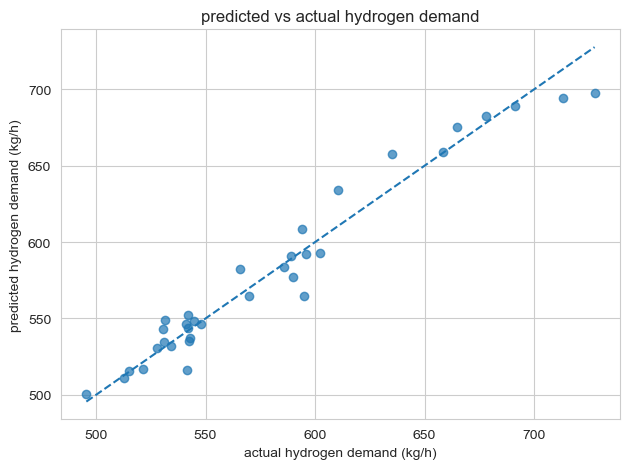

In [10]:
# predictive model evaluation: predicted values vs real values plot
plt.figure()
plt.scatter(y_test, new_preds, alpha = 0.7)

min_val = min(y_test.min(), new_preds.min())
max_val = max(y_test.max(), new_preds.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle = "--"
)

plt.title("predicted vs actual hydrogen demand")
plt.xlabel("actual hydrogen demand (kg/h)")
plt.ylabel("predicted hydrogen demand (kg/h)")
plt.tight_layout()
plt.show()


In [11]:
# define HRS candidate locations
candidate_locations = np.array([
    [5, 3],
    [6, 12],
    [11, 1],
    [7, 8],
    [4, 5],
    [2, 6],
    [9, 9],
    [3, 7],
    [6, 2],
    [4, 4],
    [13, 2],
    [4, 9],
    [1, 9],
    [3, 8],
    [8, 4]
])

# number of candidate locations
n_candidates = len(candidate_locations)

# number of days (1 week)
n_days = 7

# number of stations that are desired to be built
p = 5


In [12]:
# generate realistic future hydrogen demand
future_rows = []  # empty list

for d in range(n_days):
    for i in range(n_candidates):
        future_rows.append([
            np.random.randint(150, 500),  # VehicleCount
            np.random.uniform(0.3, 1.0),  # TrafficIndex
            np.sin(2 * np.pi * 12 / 24),  # hour_sin
            np.cos(2 * np.pi * 12 / 24),  # hour_cos
            np.sin(2 * np.pi * d / 7),  # day_sin
            np.cos(2 * np.pi * d / 7),  # day_cos
            candidate_locations[i][0],  # station_x
            candidate_locations[i][1]  # station_y
        ])

# future hydrogen demand for every candidate location
X_future = np.array(future_rows)

demand = optimal_rf_model.predict(X_future)
demand = demand.reshape(n_days, n_candidates)


C:\Users\Thvelonis\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [13]:
# definition of the central hydrogen depot
depot = np.array([[0, 0]])

# combine all 2D points
all_points = np.vstack([depot, candidate_locations])

# table of distances of all points between each other
distance_matrix = cdist(all_points, all_points)


In [14]:
# transportation cost optimization model
model = pulp.LpProblem("HRS_grid_optimal_placement", pulp.LpMinimize)  # cost minimization model

# critical assumptions for the problem
fuel_cost = 10  # in monetary units per kg of compressed hydrogen transported
truck_capacity = 1000  # 1000 kg of compressed hydrogen
station_capacity = 1500  # maximum hydrogen capacity for each station


In [15]:
# decision variables definition
# station construction
x = pulp.LpVariable.dicts("build", range(n_candidates), cat = "Binary")

# hydrogen sent from depot to station j on day d
y = pulp.LpVariable.dicts(
    "replenish",
    ((j, d) for j in range(n_candidates) for d in range(n_days)),
    lowBound = 0,
    cat = "Continuous"
)

# inventory level at station j at the end of day d
s = pulp.LpVariable.dicts(
    "storage",
    ((j, d) for j in range(n_candidates) for d in range(n_days)),
    lowBound = 0,
    upBound = station_capacity,
    cat = "Continuous"
)


In [16]:
# inventory balance
for j in range(n_candidates):
    for d in range(n_days):
        if d == 0:
            # stations start at their minimum required inventory (10%)
            model += s[(j, d)] == (0.1 * station_capacity * x[j]) + y[(j, d)] - demand[d, j] * x[j]
        else:
            model += s[(j, d)] == s[j, d - 1] + y[(j, d)] - demand[d, j] * x[j]

# minimum inventory constraint (10%)
for j in range(n_candidates):
    for d in range(n_days):
        model += s[(j, d)] >= 0.1 * station_capacity * x[j]

# inventory must never go negative
for j in range(n_candidates):
    for d in range(n_days):
        model += s[(j, d)] >= 0


In [17]:
# only built stations can receive hydrogen - refuel only if built
for j in range(n_candidates):
    for d in range(n_days):
        model += y[(j, d)] <= station_capacity * x[j]

# prevention of extreme inventory accumulation
for j in range(n_candidates):
    for d in range(n_days):
        model += s[(j, d)] <= station_capacity * x[j]


In [18]:
# objective function - this is the function that solver is trying to optimize
model += pulp.lpSum(
    distance_matrix[0, j + 1] * fuel_cost * y[(j, d)] / truck_capacity
    for j in range(n_candidates)
    for d in range(n_days)
)

# force exactly p stations to be built
model += pulp.lpSum(x[i] for i in range(n_candidates)) == p

# solve the optimization problem
model.solve()

# print statement to see the result of the optimization
print(f"optimization model status: {pulp.LpStatus[model.status]}")


optimization model status: Optimal


In [19]:
# import libraries for visualizations
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# visualization style setup
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("paper", font_scale = 1.2)

# extract selected stations (built stations)
selected_stations = [i for i in range(n_candidates) if x[i].varValue is not None and x[i].varValue > 0.5]  # list

# extract inventory and replenishment data for selected stations
storage_data = np.zeros((len(selected_stations), n_days))
replenish_data = np.zeros((len(selected_stations), n_days))
demand_data = np.zeros((len(selected_stations), n_days))

for idx, j in enumerate(selected_stations):
    for d in range(n_days):
        storage_data[idx, d] = s[(j, d)].varValue
        replenish_data[idx, d] = y[(j, d)].varValue
        demand_data[idx, d] = demand[d, j]


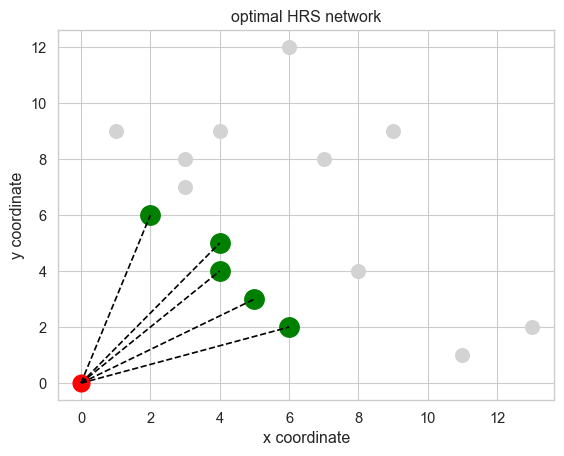

In [20]:
# visualization: optimal HRS network to minimize hydrogen transportation costs, which arise during HRS refueling
plt.figure()
plt.grid(True)
plt.title("optimal HRS network")
plt.xlabel("x coordinate")
plt.ylabel("y coordinate")

# plotting: central depot
plt.scatter(depot[0][0], depot[0][1], c = "red", s = 150, label = "central depot")

# plotting: unselected candidate locations
unbuilt = [j for j in range(n_candidates) if j not in selected_stations]  # list of candidate locations
plt.scatter(candidate_locations[unbuilt, 0], candidate_locations[unbuilt, 1], c = "lightgrey", s = 100, label = "rejected locations")  # rejected locations

# plotting: selected locations and truck routes
for j in selected_stations:
    sx, sy = candidate_locations[j]
    plt.scatter(sx, sy, c = "green", s = 200, label = "selected locations")  # selected locations
    plt.plot([depot[0][0], sx], [depot[0][1], sy], "k--")  # truck routes

plt.show()


In [21]:
# total hydrogen transportation cost in the optimal case
# calculate total transportation cost
total_transportation_cost_in_optimal_case = sum(
    distance_matrix[0, j + 1] * fuel_cost * y[(j, d)].varValue / truck_capacity
    for j in range(n_candidates)
    for d in range(n_days)
    if y[(j, d)].varValue is not None
)

# print total hydrogen transportation cost in the optimal case
print(f"Total hydrogen transportation cost in the optimal case: {total_transportation_cost_in_optimal_case:.3f} monetary units")


Total hydrogen transportation cost in the optimal case: 1281.273 monetary units


In [22]:
# total truck routes for a week
# initialize routes counter
total_routes = 0

# count every replenishment action as one truck route
for j in range(n_candidates):
    for d in range(n_days):
        delivered_h2 = y[(j, d)].varValue

        # if hydrogen was transported
        if delivered_h2 is not None and delivered_h2 > 0:
            routes = np.ceil(delivered_h2 / truck_capacity)
            total_routes += routes

# print total truck routes for a week
print(f"Total truck routes for a week in the optimal case: {int(total_routes)}")


Total truck routes for a week in the optimal case: 35


Randomly selected locations: 
[12  5 14 10  3]


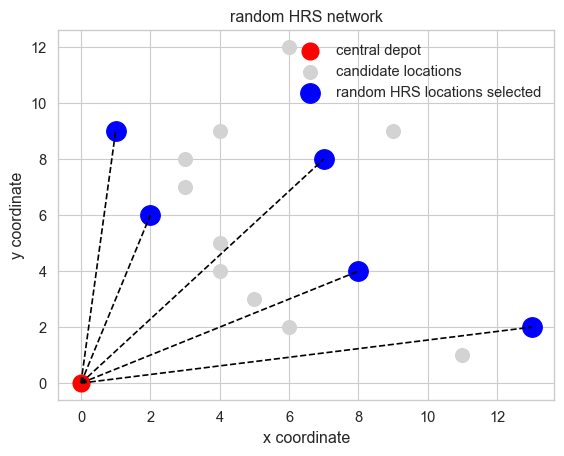

In [23]:
# to compare a random HRS grid with the optimal HRS grid, I will randomly select 5 of the candidate locations to build HRS
# random HRS grid
# randomly select 5 candidate locations
random_stations = np.random.choice(range(n_candidates), size = p, replace = False)
print("Randomly selected locations: ")
print(random_stations)

# visualization: random HRS grid
plt.figure()
plt.scatter(depot[0][0], depot[0][1], c = "red", s = 150, label = "central depot")
plt.scatter(candidate_locations[:, 0], candidate_locations[:, 1], c = "lightgray", s = 100, label = "candidate locations")
plt.scatter(candidate_locations[random_stations, 0], candidate_locations[random_stations, 1], c = "blue", s = 200, label = "random HRS locations selected")

# visualization: truck routes from central depot
for j in random_stations:
    sx, sy = candidate_locations[j]
    plt.plot([depot[0][0], sx], [depot[0][1], sy], "k--")

plt.title("random HRS network")
plt.xlabel("x coordinate")
plt.ylabel("y coordinate")
plt.grid(True)
plt.legend()
plt.show()


In [24]:
# total hydrogen transportation cost in the random case
# calculate total transportation cost
total_transportation_cost_in_random_case = 0
for j in random_stations:
    for d in range(n_days):
        transported_h2 = demand[d, j]
        transp_cost = (distance_matrix[0, j + 1] * fuel_cost * transported_h2 / truck_capacity)
        total_transportation_cost_in_random_case += transp_cost

print(f"Total hydrogen transportation cost in the random case: {total_transportation_cost_in_random_case:.3f} monetary units")


Total hydrogen transportation cost in the random case: 2017.819 monetary units


In [25]:
# total truck routes for a week in the random case
# initialize routes counter
random_total_routes = 0
for j in random_stations:
    for d in range(n_days):
        delivered_h2 = demand[d, j]
        if delivered_h2 > 0:
            routes = np.ceil(delivered_h2 / truck_capacity)
            random_total_routes += routes

print(f"Total truck routes for a week in the random case: {int(random_total_routes)}")


Total truck routes for a week in the random case: 35


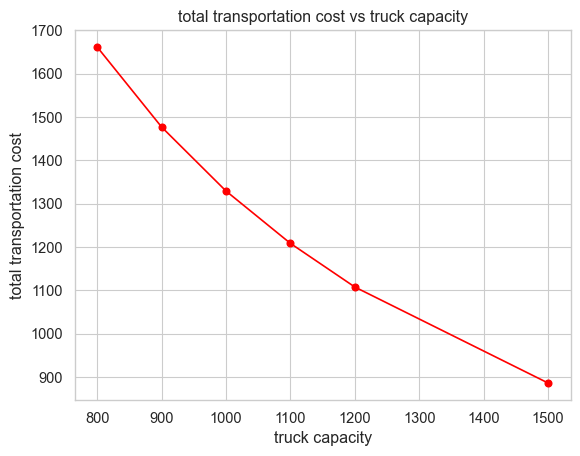

In [26]:
# visualization: change in the total cost of hydrogen transportation as a function of the truck capacity
# visualization assumptions: constant fuel price (fuel_cost = 10), all HRS have the same capacity (station_capacity = 1500)

# data from code runs with different truck capacity values
variable_truck_capacity = [800, 900, 1000, 1100, 1200, 1500]  # list
total_cost_of_hydrogen_transportation = [1661.67, 1477.04, 1329.33, 1208.49, 1107.78, 886.22]  # list

# chart creation
plt.figure()
plt.plot(variable_truck_capacity, total_cost_of_hydrogen_transportation, marker = "o", linestyle = "-", color = "red")
plt.title("total transportation cost vs truck capacity")
plt.xlabel("truck capacity")
plt.ylabel("total transportation cost")
plt.grid(True)
plt.show()


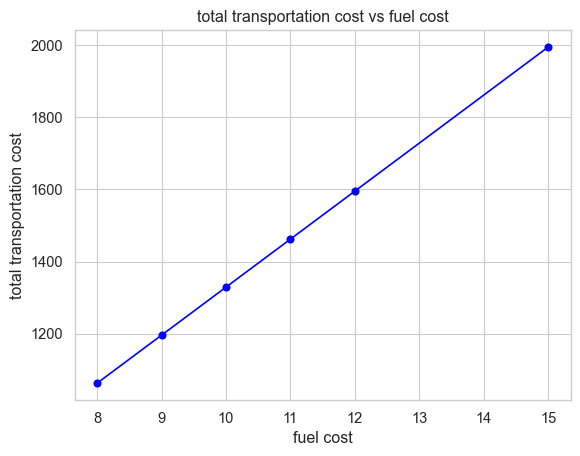

In [27]:
# visualization: change in the total cost of hydrogen transportation as a function of the fuel cost
# visualization assumptions: constant truck capacity (truck_capacity = 1000), all HRS have the same capacity (station_capacity = 1500)

# data from code runs with different fuel cost values
variable_fuel_cost = [8, 9, 10, 11, 12, 15]  # list
total_cost_of_transportation = [1063.47, 1196.4, 1329.33, 1462.27, 1595.2, 1994]  # list

# chart creation
plt.figure()
plt.plot(variable_fuel_cost, total_cost_of_transportation, marker = "o", linestyle = "-", color = "blue")
plt.title("total transportation cost vs fuel cost")
plt.xlabel("fuel cost")
plt.ylabel("total transportation cost")
plt.grid(True)
plt.show()


In [28]:
# another scenario: nearby candidate stations with small storage, and distant candidate stations with large storage
# minimum and maximum capacities definition
min_capacity = 500  # minimum HRS capacity
max_capacity = 2000  # maximum HRS capacity

# distance from depot to every 2D candidate location
distances_from_depot = distance_matrix[0, 1:]

# normalize distances (min-max scaling)
norm_dist = (
    (distances_from_depot - distances_from_depot.min()) / (distances_from_depot.max() - distances_from_depot.min())
)

# capacities based on distance from central depot
stations_capacities = (
    min_capacity + norm_dist * (max_capacity - min_capacity)
)

stations_capacities = np.round(stations_capacities, 0)

# display of all station capacities
capacity_df = pd.DataFrame({
    "station": range(n_candidates),
    "distance from central depot": distances_from_depot,
    "capacity (kg)": stations_capacities
})

display(capacity_df)


,station,distance from central depot,capacity (kg)
0,0,5.830952,534.0
1,1,13.416408,2000.0
2,2,11.045361,1542.0
3,3,10.630146,1461.0
4,4,6.403124,644.0
5,5,6.324555,629.0
6,6,12.727922,1867.0
7,7,7.615773,879.0
8,8,6.324555,629.0
9,9,5.656854,500.0


In [29]:
# optimization model for the last scenario
model2 = pulp.LpProblem("HRS_grid_optimal_placement_with_variable_stations_capacity", pulp.LpMinimize)

# decision variables
# station construction
x2 = pulp.LpVariable.dicts("build2", range(n_candidates), cat = "Binary")

# hydrogen sent from depot to station j on day d
y2 = pulp.LpVariable.dicts("replenish2", ((j, d) for j in range(n_candidates) for d in range(n_days)), lowBound = 0, cat = "Continuous")

# inventory level at station j at the end of day d
s2 = pulp.LpVariable.dicts("storage2", ((j, d) for j in range(n_candidates) for d in range(n_days)), lowBound = 0, cat = "Continuous")

# number of integer truck trips sent to station j on day d
trucks2 = pulp.LpVariable.dicts(
    "trucks_sent2",
    ((j, d) for j in range(n_candidates) for d in range(n_days)),
    lowBound = 0,
    cat = "Integer"
)

# the continuous hydrogen delivered cannot exceed the total capacity of the truck sent
for j in range(n_candidates):
    for d in range(n_days):
        model2 += y2[(j, d)] <= trucks2[(j, d)] * truck_capacity

# inventory balance
for j in range(n_candidates):
    cap = stations_capacities[j]
    for d in range(n_days):
        if d == 0:
            model2 += (s2[(j, d)] == (0.1 * cap * x2[j]) + y2[(j, d)] - demand[d, j] * x2[j])
        else:
            model2 += (s2[(j, d)] == s2[(j, d - 1)] + y2[(j, d)] - demand[d, j] * x2[j])

# minimum inventory
for j in range(n_candidates):
    cap = stations_capacities[j]
    for d in range(n_days):
        model2 += s2[(j, d)] >= 0.1 * cap * x2[j]

# replenishment only if built
for j in range(n_candidates):
    cap = stations_capacities[j]
    for d in range(n_days):
        model2 += y2[(j, d)] <= cap * x2[j]

# storage upper bound
for j in range(n_candidates):
    cap = stations_capacities[j]
    for d in range(n_days):
        model2 += s2[(j, d)] <= cap * x2[j]

# build exactly p stations
model2 += pulp.lpSum(x2[a] for a in range(n_candidates)) == p

# objective function: pay for the whole truck, regardless of how full it is
model2 += pulp.lpSum(
    distance_matrix[0, j + 1] * fuel_cost * trucks2[(j, d)]
    for j in range(n_candidates)
    for d in range(n_days)
)

# solving the optimization problem
model2.solve()
print("optimization model status:", pulp.LpStatus[model2.status])


optimization model status: Optimal


In [30]:
# selected HRS in this scenario
selected_stations_2 = [
    i for i in range(n_candidates)
    if x2[i].varValue is not None and x2[i].varValue > 0.5
]

print("selected stations in this scenario:", selected_stations_2)


selected stations in this scenario: [7, 8, 12, 13, 14]


In [31]:
# comparison: scenario with equal capacity of all stations vs scenario with variable station capacity
# equal station capacity scenario (first scenario) vs variable station capacity scenario (second scenario)
hrs_of_first_scenario = selected_stations
hrs_of_second_scenario = selected_stations_2

comparison_df = pd.DataFrame({
    "equal capacity scenario": hrs_of_first_scenario,
    "variable capacity scenario": hrs_of_second_scenario
})

display(comparison_df)


,equal capacity scenario,variable capacity scenario
0,0,7
1,4,8
2,5,12
3,8,13
4,9,14


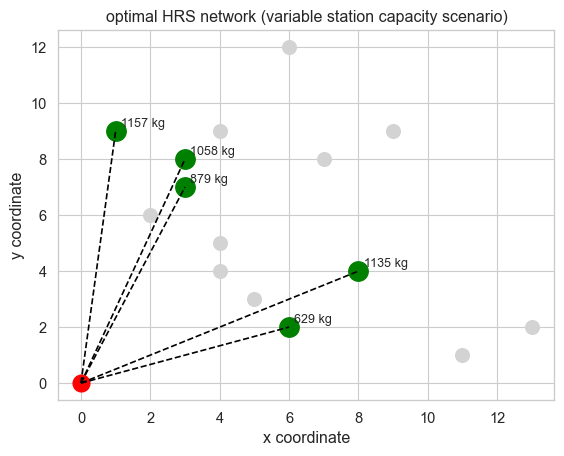

In [32]:
# visualization: optimal HRS network (variable station capacity scenario)
plt.figure()
plt.grid(True)
plt.title("optimal HRS network (variable station capacity scenario)")
plt.xlabel("x coordinate")
plt.ylabel("y coordinate")

# plotting: central depot
plt.scatter(depot[0][0], depot[0][1], c = "red", s = 150, label = "central depot")

# plotting: selected locations and truck routes
for j in selected_stations_2:
    sx, sy = candidate_locations[j]
    cap = stations_capacities[j]
    plt.scatter(sx, sy, c = "green", s = 200, label = "selected locations")
    plt.plot([depot[0][0], sx], [depot[0][1], sy], "k--")
    plt.text(sx + 0.15, sy + 0.15, f"{int(cap)} kg", fontsize = 9)

# plotting: rejected locations
unbuilt2 = [j for j in range(n_candidates) if j not in selected_stations_2]
plt.scatter(candidate_locations[unbuilt2, 0], candidate_locations[unbuilt2, 1], c = "lightgrey", s = 100, label = "rejected locations")


In [33]:
# total hydrogen transportation cost comparison
# equal station capacity scenario (first scenario) vs variable station capacity scenario (second scenario)
first_scenario_total_cost = sum(
    distance_matrix[0, j + 1] * fuel_cost * y[(j, d)].varValue / truck_capacity
    for j in range(n_candidates)
    for d in range(n_days)
)

second_scenario_total_cost = sum(
    distance_matrix[0, j + 1] * fuel_cost * y2[(j, d)].varValue / truck_capacity
    for j in range(n_candidates)
    for d in range(n_days)
)

print(f"equal station capacity scenario total cost: {first_scenario_total_cost:.2f}")
print(f"variable station capacity scenario total cost: {second_scenario_total_cost:.2f}")


equal station capacity scenario total cost: 1281.27
variable station capacity scenario total cost: 1666.61


In [34]:
# percentage cost difference
cost_difference = second_scenario_total_cost - first_scenario_total_cost
percentage_change = cost_difference / first_scenario_total_cost * 100
print(f"absolute cost difference: {cost_difference:.2f}")
print(f"percentage change: {percentage_change:.2f} %")


absolute cost difference: 385.34
percentage change: 30.07 %
